In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
import os
import pandas as pd
import numpy as np

In [4]:
# Load TSV file
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_geo_prostate_andro.tsv", sep="\t")

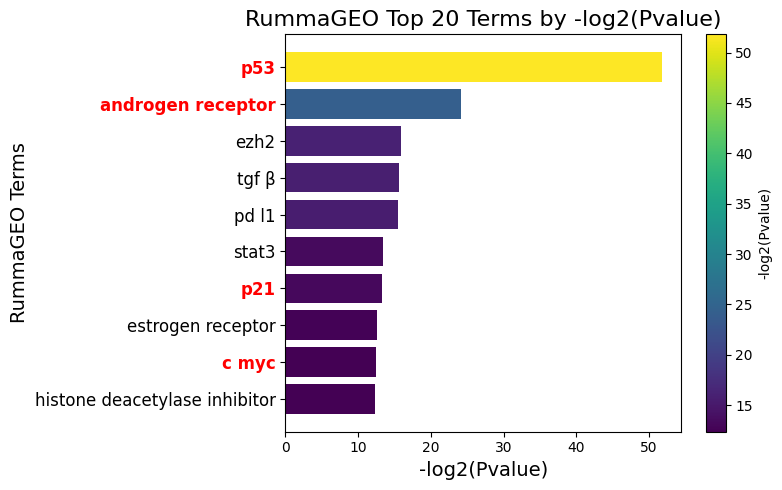

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# --- Prepare the dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

# Take top 20 instead of top 10
df_top20 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top20 = df_top20.sort_values("-log2(Pvalue)", ascending=True)

# Clean up term names
def clean_term(term):
    term = re.sub(r"\s+WP\d+$", "", term)
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGAKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top20["term_clean"] = df_top20["term"].apply(clean_term)

# Color mapping
norm = mcolors.Normalize(vmin=df_top20["-log2(Pvalue)"].min(),
                         vmax=df_top20["-log2(Pvalue)"].max())
cmap = cm.viridis

# Terms to highlight
highlight_term = ["p53", "androgen receptor", "c myc", "p21"]

# Create figure (single panel)
fig, ax = plt.subplots(figsize=(8, 5))

# Plot
bars = ax.barh(
    df_top20["term_clean"],
    df_top20["-log2(Pvalue)"],
    color=cmap(norm(df_top20["-log2(Pvalue)"]))
)

# Highlight terms
for label in ax.get_yticklabels():
    label.set_fontsize(12)
    if label.get_text().lower() in highlight_term:
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(Pvalue)", fontsize=14)
ax.set_ylabel("RummaGEO Terms", fontsize=14)
ax.set_title("RummaGEO Top 20 Terms by -log2(Pvalue)", fontsize=16)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="-log2(Pvalue)")

plt.tight_layout()
fig.savefig("../../figures/RummaGEO_finale.png", dpi=300, bbox_inches="tight")
plt.show()
